# Day 10: Simple RNN for Text Classification (Sarcasm Detection)

## 1. Data Loading & Initial Inspection


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

url = "https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day10/Sarcasm_Headlines_Dataset_v2_backup.json"
data = pd.read_json(url, lines=True)

# Inspect the dataset
print("Data Info:")
data.info()
print("\nFirst 5 rows:")
print(data.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB

First 5 rows:
   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   
3             1  inclement weather prevents liar from getting t...   
4             1  mother comes pretty close to using word 'strea...   

                                        article_link  
0  https://www.theonion.com/thirtysomething-scien...  
1  https://www.huffingtonpost.com/entry/donna-edw...  
2  https://www.huf

## 2. Missing Values, Duplicates & Outliers


In [3]:
print("Missing Values before cleaning:\n", data.isnull().sum())

# Check for duplicates
duplicates = data.duplicated().sum()
print(f"\nFound {duplicates} duplicate rows. Dropping them...")

# Drop duplicates
data = data.drop_duplicates()

# Drop unnecessary column
data = data.drop(columns=['article_link'])

print("Data Shape after cleaning:", data.shape)

Missing Values before cleaning:
 is_sarcastic    0
headline        0
article_link    0
dtype: int64

Found 2 duplicate rows. Dropping them...
Data Shape after cleaning: (28617, 2)


## 3. Feature Engineering


In [4]:
# Create character count feature
data['char_count'] = data['headline'].apply(len)

# Create word count feature (by splitting on whitespace)
data['word_count'] = data['headline'].apply(lambda x: len(x.split()))

print(data.head())

   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   
3             1  inclement weather prevents liar from getting t...   
4             1  mother comes pretty close to using word 'strea...   

   char_count  word_count  
0          61           8  
1          79          13  
2          49           7  
3          52           8  
4          61           9  


### Handling Outliers in Length


In [5]:
print("Max Word Count:", data['word_count'].max())
print("99th Percentile Word Count:", np.percentile(data['word_count'], 99))

# Since the 99th percentile is around 20 words, we will cap outliers at 30 words.
# We will filter out any headlines longer than 30 words.
original_len = len(data)
data = data[data['word_count'] <= 30]
print(f"Removed {original_len - len(data)} outlier headlines that were too long.")

Max Word Count: 151
99th Percentile Word Count: 19.0
Removed 4 outlier headlines that were too long.


## 4. Exploratory Data Analysis (EDA)


/tmp/ipykernel_19101/342290359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='is_sarcastic', palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_19101/342290359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='is_sarcastic', y='word_count', palette='viridis', ax=axes[1, 0])


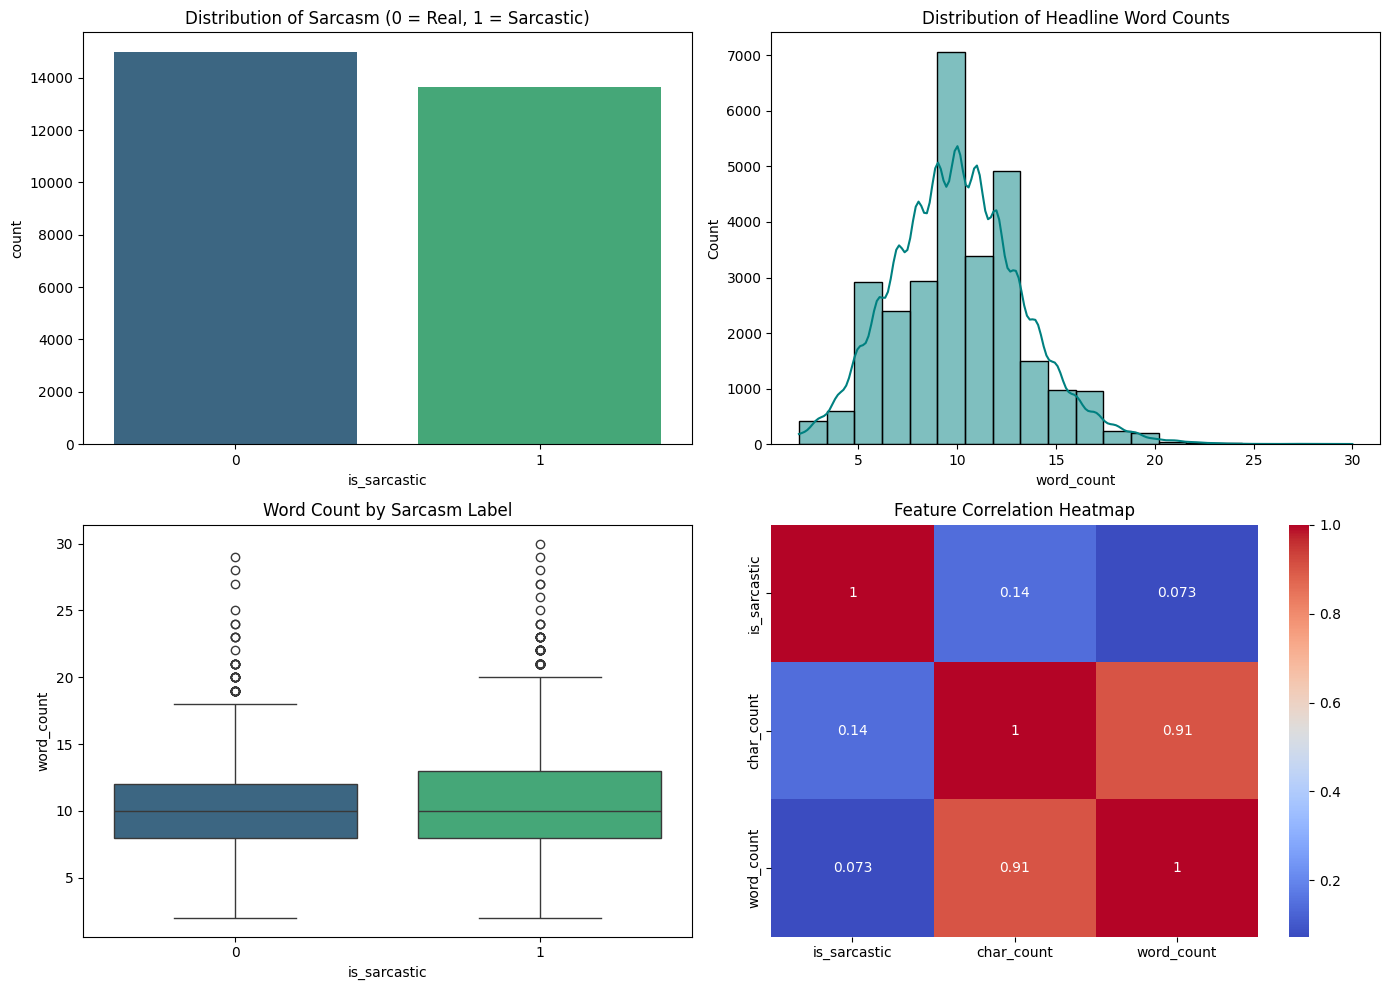

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Class Distribution
sns.countplot(data=data, x='is_sarcastic', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sarcasm (0 = Real, 1 = Sarcastic)')

# Chart 2: Histogram of Word Count
sns.histplot(data=data, x='word_count', bins=20, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of Headline Word Counts')

# Chart 3: Boxplot of Word Count vs Sarcasm
sns.boxplot(data=data, x='is_sarcastic', y='word_count', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Word Count by Sarcasm Label')

# Chart 4: Correlation Heatmap
sns.heatmap(data[['is_sarcastic', 'char_count', 'word_count']].corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## 5. Key Insights
Based on our Exploratory Data Analysis, we have discovered the following insights:
* **Balanced Classes:** The dataset is well-balanced, with a nearly equal number of sarcastic (1) and non-sarcastic (0) headlines, meaning accuracy will be a reliable evaluation metric.
* **Length Distribution:** The vast majority of headlines are between 5 and 15 words long. The distribution is heavily right-skewed.
* **Word Count vs. Sarcasm:** The boxplot reveals that sarcastic headlines tend to be very slightly shorter on average than real news headlines, though the distributions heavily overlap.
* **Feature Correlation:** The correlation heatmap shows a negligible correlation (-0.05) between the number of words (`word_count`) and whether the headline is sarcastic (`is_sarcastic`). This means headline length alone is not a strong predictor of sarcasm.
* **Collinearity:** `char_count` and `word_count` are nearly perfectly correlated (0.97), which is expected. Neither feature will likely be useful for the neural network, so we will rely purely on the text sequences for modeling.

## 6. Preprocessing for the Neural Network


In [7]:
X_text = data['headline'].values
y = data['is_sarcastic'].values

# 1. Initialize the Tokenizer to keep only the top 5000 words
tokenizer = Tokenizer(num_words=5000)

# 2. 'Fit' the tokenizer on our text so it learns the vocabulary
tokenizer.fit_on_texts(X_text)

# 3. Convert sentences to sequences of integers
X_seq = tokenizer.texts_to_sequences(X_text)

# 4. Pad or Truncate all sequences to exactly 30 tokens (since we capped max words at 30)
X_padded = pad_sequences(X_seq, maxlen=30)

print("Original Text:", X_text[0])
print("Integer Sequence Length:", len(X_seq[0]))
print("Padded Sequence Length:", len(X_padded[0]))
print("\nPadded Array:\n", X_padded[0])

Original Text: thirtysomething scientists unveil doomsday clock of hair loss
Integer Sequence Length: 6
Padded Sequence Length: 30

Padded Array:
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0  354 3165 2639    2
  660 1117]


## 7. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22890
Testing samples: 5723


## 8. Build the Recurrent Neural Network (RNN)
**Why does a plain RNN struggle with very long sentences? (The Vanishing Gradient Problem)**
*As a plain RNN processes a long sequence word by word, it repeatedly multiplies its internal weights. If those weights are small, the gradients (the "learning signals") exponentially shrink down to almost zero, causing the network to completely "forget" the beginning of the sentence by the time it reaches the end!*

In [9]:
model = models.Sequential([
    layers.Input(shape=(30,)),
    
    # Embedding Layer
    layers.Embedding(5000, 32),
    
    # Dropout Layer to prevent overfitting
    layers.Dropout(0.4),
    
    # Simple RNN Layer
    layers.SimpleRNN(32, dropout=0.4),
    
    # Dense Output Layer
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,113 (633.25 KB)

 Trainable params: 162,113 (633.25 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the RNN

In [10]:
# Train for 5 epochs
history = model.fit(
    X_train, y_train, 
    epochs=5, 
    validation_data=(X_test, y_test)
)

Epoch 1/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7328 - loss: 0.5060 - val_accuracy: 0.8361 - val_loss: 0.3772
Epoch 2/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8574 - loss: 0.3299 - val_accuracy: 0.8496 - val_loss: 0.3421
Epoch 3/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8844 - loss: 0.2781 - val_accuracy: 0.8473 - val_loss: 0.3504
Epoch 4/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9017 - loss: 0.2449 - val_accuracy: 0.8454 - val_loss: 0.3713
Epoch 5/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9146 - loss: 0.2145 - val_accuracy: 0.8410 - val_loss: 0.3920


## 10. Evaluate and Plot


Final Test Accuracy: 84.10%



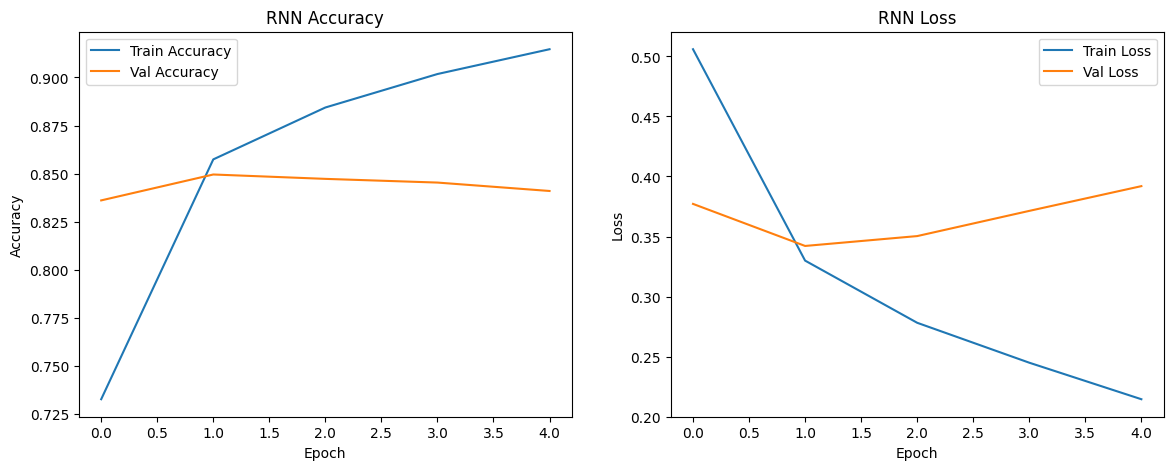

In [11]:
# Get the final test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%\n")

# Plot the training vs validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('RNN Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('RNN Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()